# Recommendation vs Normalized Hours EDA

The background problem for this notebook is because the API for GetOwnedGames does not include recommendation and early_access information, which are required to compute the interaction score. They are available through [https://store.steampowered.com/appreviews/{appid}](https://store.steampowered.com/appreviews/{appid}) but requiring us to loop the review pages until the relevant user reviews are found, which will significantly add much more running time. Hence, this notebook is made to provide a base assumption to the expected recommendation based on the normalized playtime hours.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [ ]:
BASE_DIR = Path.cwd().resolve()
GAME_REVIEW_PATH = BASE_DIR / 'tables' / 'production' / 'GAME_REVIEW.csv'
GAME_DATA_PATH = BASE_DIR / 'tables' / 'production' / 'GAME_DATA.csv'

print('BASE_DIR:', BASE_DIR)
print('GAME_REVIEW_PATH:', GAME_REVIEW_PATH)
print('GAME_DATA_PATH:', GAME_DATA_PATH)

BASE_DIR: /Users/salirafi/Documents/Personal Project/Steam Recommender/notebooks
GAME_REVIEW_PATH: /Users/salirafi/Documents/Personal Project/Steam Recommender/notebooks/tables/production/GAME_REVIEW.csv
GAME_DATA_PATH: /Users/salirafi/Documents/Personal Project/Steam Recommender/notebooks/tables/production/GAME_DATA.csv


In [ ]:
review_df = pd.read_csv(GAME_REVIEW_PATH, usecols=['item_id', 'hours', 'recommendation'])
game_df = pd.read_csv(GAME_DATA_PATH, usecols=['item_id', 'median_playtime_forever'])

review_df['item_id'] = pd.to_numeric(review_df['item_id'], errors='coerce')
review_df['hours'] = pd.to_numeric(review_df['hours'], errors='coerce').fillna(0.0)
review_df['recommendation'] = pd.to_numeric(review_df['recommendation'], errors='coerce').fillna(0).astype(int)

game_df['item_id'] = pd.to_numeric(game_df['item_id'], errors='coerce')
game_df['median_playtime_forever'] = pd.to_numeric(game_df['median_playtime_forever'], errors='coerce').fillna(0.0)

df = review_df.merge(game_df, on='item_id', how='left')
df['median_hours'] = np.maximum(df['median_playtime_forever'], 0.0)
df['normalized_hours'] = df['hours'] / df['median_hours'] # normalized by the median playtime of the game (provided in the dataset)
df['log_normalized_hours'] = np.log1p(df['normalized_hours'])

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['item_id', 'hours', 'recommendation', 'normalized_hours'])
df = df[df['normalized_hours'] >= 0].copy()

print('Rows:', len(df))
df.head()

Rows: 104908977


,item_id,hours,recommendation,median_playtime_forever,median_hours,normalized_hours,log_normalized_hours
0,70,407.0,1,147.0,147.0,2.768707,1.326732
1,280,2205.0,1,92.0,92.0,23.967391,3.217571
2,241320,8860.0,1,182.0,182.0,48.681319,3.905629
3,275850,9484.0,1,1239.0,1239.0,7.654560,2.158086
4,546560,6549.0,1,384.0,384.0,17.054688,2.893405


/var/folders/kz/dlw3ql7s3ds1_72hwlw7_t540000gn/T/ipykernel_60627/4268619166.py:40: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[1].set_xlim(0.0, 10)


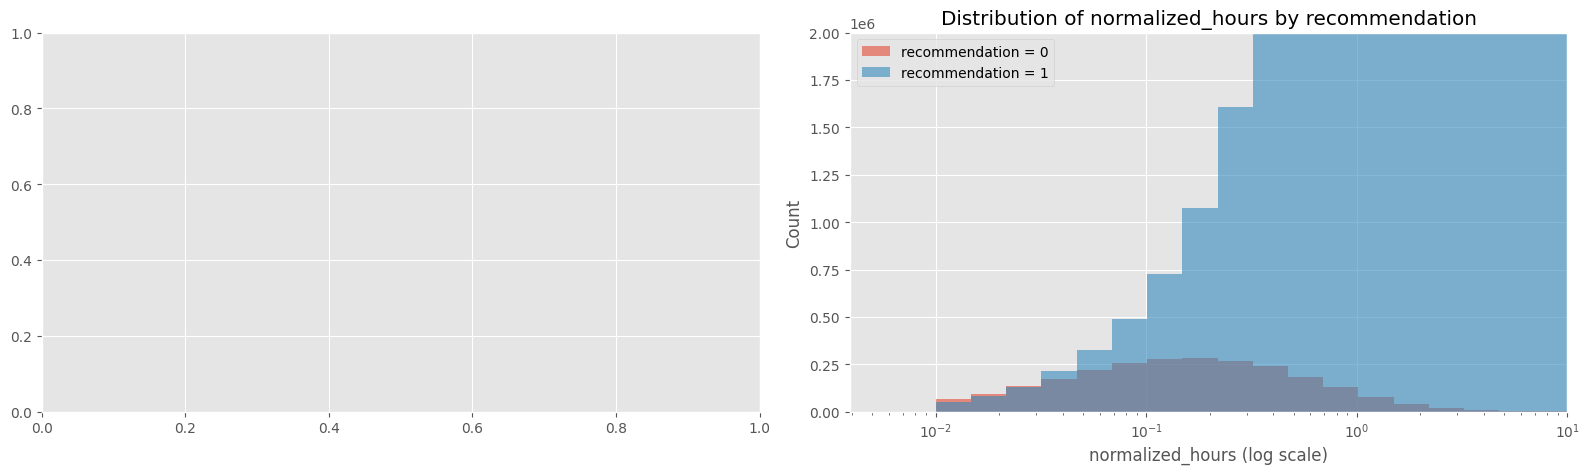

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(
    df.loc[df['recommendation'] == 0, 'log_normalized_hours'],
    bins=60,
    alpha=0.6,
    label='recommendation = 0',
)
axes[0].hist(
    df.loc[df['recommendation'] == 1, 'log_normalized_hours'],
    bins=60,
    alpha=0.6,
    label='recommendation = 1',
)
axes[0].set_title('Distribution of log(1 + normalized_hours) by recommendation')
axes[0].set_xlabel('log(1 + normalized_hours)')
axes[0].set_ylabel('Count')
axes[0].legend()

plot_df = df[df['normalized_hours'] > 0].copy()
axes[1].hist(
    plot_df.loc[plot_df['recommendation'] == 0, 'normalized_hours'],
    bins=np.logspace(-2, np.log10(max(plot_df['normalized_hours'].max(), 1.0)), 50),
    alpha=0.6,
    label='recommendation = 0',
)
axes[1].hist(
    plot_df.loc[plot_df['recommendation'] == 1, 'normalized_hours'],
    bins=np.logspace(-2, np.log10(max(plot_df['normalized_hours'].max(), 1.0)), 50),
    alpha=0.6,
    label='recommendation = 1',
)
axes[1].set_xscale('log')
axes[1].set_title('Distribution of normalized_hours by recommendation')
axes[1].set_xlabel('normalized_hours (log scale)')
axes[1].set_ylabel('Count')
axes[1].legend()

axes[1].set_ylim(0, 0.2e7)
axes[1].set_xlim(0.0, 10)

plt.tight_layout()
plt.show()

In [14]:
bin_df = df.copy()
bin_df['normalized_hours_clip'] = bin_df['normalized_hours'].clip(upper=bin_df['normalized_hours'].quantile(0.99))
bin_df['hours_bin'] = pd.qcut(bin_df['normalized_hours_clip'], q=20, duplicates='drop')

recommendation_by_bin = (
    bin_df.groupby('hours_bin', observed=False)
    .agg(
        sample_size=('recommendation', 'size'),
        recommend_rate=('recommendation', 'mean'),
        normalized_hours_min=('normalized_hours', 'min'),
        normalized_hours_median=('normalized_hours', 'median'),
        normalized_hours_max=('normalized_hours', 'max'),
    )
    .reset_index()
)

recommendation_by_bin

,hours_bin,sample_size,recommend_rate,normalized_hours_min,normalized_hours_median,normalized_hours_max
0,"(-0.001, 0.242]",5245461,0.680641,0.000000,0.109804,2.421413e-01
1,"(0.242, 0.538]",5245452,0.903943,0.242142,0.387755,5.381415e-01
2,"(0.538, 0.838]",5245461,0.964740,0.538144,0.689655,8.383485e-01
3,"(0.838, 1.122]",5245431,0.984444,0.838350,0.980769,1.121528e+00
4,"(1.122, 1.419]",5245455,0.991224,1.121530,1.266979,1.419255e+00
5,"(1.419, 1.75]",5245482,0.994403,1.419257,1.580071,1.750309e+00
6,"(1.75, 2.125]",5246676,0.996446,1.750310,1.931698,2.125000e+00
7,"(2.125, 2.557]",5244193,0.997553,2.125011,2.333333,2.556952e+00
8,"(2.557, 3.067]",5245446,0.998372,2.556953,2.800654,3.067251e+00
9,"(3.067, 3.681]",5245459,0.998822,3.067256,3.359441,3.681131e+00


In [9]:
candidate_thresholds = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]

threshold_rows = []
for threshold in candidate_thresholds:
    subset = df[df['normalized_hours'] >= threshold]
    threshold_rows.append({
        'threshold': threshold,
        'sample_size': len(subset),
        'recommend_rate': subset['recommendation'].mean() if len(subset) else np.nan,
        'median_normalized_hours': subset['normalized_hours'].median() if len(subset) else np.nan,
    })

pd.DataFrame(threshold_rows)

,threshold,sample_size,recommend_rate,median_normalized_hours
0,0.25,108541995,0.972893,219.027027
1,0.50,108456255,0.973285,219.360246
2,1.00,108251227,0.974285,220.123609
3,2.00,107811158,0.976235,221.818182
4,3.00,107378489,0.977916,223.456163
5,5.00,106569918,0.980667,226.582614
6,10.00,104526902,0.986159,234.684685
